<a href="https://colab.research.google.com/github/sameh-mo/disease-risk-prediction/blob/main/Liver_Disease_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import os

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import joblib
import warnings
warnings.filterwarnings('ignore')

# 📌 **1. Business Understanding**

The goal of this project is to build a machine learning model that can accurately predict liver disease based on patient medical attributes. Early detection of liver disease is important for improving treatment outcomes and reducing health risks.

In this project, two machine learning algorithms will be used: **K-Nearest Neighbors (KNN)** and **Decision Tree**. The performance of both models will be compared to determine the most suitable approach for this dataset.

The workflow of the project includes:

Data collection and loading from a real-world dataset.
Exploratory Data Analysis (EDA) to understand the structure and patterns in the data.
Data preprocessing including handling missing values and encoding categorical variables.
Splitting the data into training, validation, and testing sets.
Building and evaluating machine learning models.

The final objective is to develop a reliable classification model that can assist in predicting liver disease with good accuracy and generalization ability.

The dataset contains demographic, lifestyle, clinical, and laboratory features used to predict liver disease classification.

| Column Name            | Description                                     |
| ---------------------- | ----------------------------------------------- |
| Age                    | Age of the individual (in years)                |
| Gender                 | Biological sex of the individual                |
| Occupation             | Job or profession category                      |
| BMI                    | Body Mass Index (weight/height²)                |
| Obesity_Class          | Classification of obesity level                 |
| Waist_Circumference    | Waist measurement (cm)                          |
| Diet_Quality           | Quality of diet (e.g., good/average/poor)       |
| Physical_Activity      | Level of physical activity                      |
| Sleep_Hours            | Average daily sleep duration (hours)            |
| Smoking_Status         | Smoking behavior status                         |
| Alcohol_Consumption    | Alcohol usage pattern                           |
| Sym_Fatigue            | Presence of fatigue symptoms (0/1)              |
| Sym_Jaundice           | Presence of jaundice symptoms (0/1)             |
| Sym_Abdominal_Pain     | Presence of abdominal pain (0/1)                |
| Sym_Itching            | Presence of itching (0/1)                       |
| Sym_Ascites            | Presence of ascites (fluid in abdomen) (0/1)    |
| Sym_Dark_Urine         | Presence of dark urine symptom (0/1)            |
| Sym_Weight_Loss        | Presence of unexplained weight loss (0/1)       |
| Comorb_Diabetes        | Presence of diabetes (0/1)                      |
| Comorb_Hypertension    | Presence of hypertension (0/1)                  |
| Comorb_Genetic_History | Family history of liver disease (0/1)           |
| ALT                    | Alanine Aminotransferase level (liver enzyme)   |
| AST                    | Aspartate Aminotransferase level (liver enzyme) |
| Bilirubin              | Bilirubin level in blood                        |
| Albumin                | Blood albumin level                             |
| Platelets              | Platelet count                                  |
| Alk_Phosphatase        | Alkaline phosphatase enzyme level               |
| GGT                    | Gamma-glutamyl transferase enzyme level         |
| Triglycerides          | Blood triglyceride level                        |
| INR                    | Blood clotting index                            |
| Source                 | Data source identifier                          |
| Liver_Disease_Class    | Target variable indicating liver disease class  |


# 🧹 **2. Load Data**

In [2]:
# download dataset form kaggel
path = kagglehub.dataset_download("priyankabarik/liver-diseases")

# file name
file_name_training = "Training_Liver_Disease_Dataset.csv"
file_name_testing = "Testing_Liver_Disease_Dataset.csv"

# loading Dataset func as DF
def get_data(file_name: str):
  """
    Load a dataset file from Kaggle using kagglehub.

    This function loads a specified file from the
    'priyankabarik/liver-diseases' dataset and returns
    it as a pandas DataFrame.

    Args:
        file_path (str): Name of the file
            'Training_Liver_Disease_Dataset.csv').

    Returns:
        pandas.DataFrame: Loaded dataset.

    """
  df =  kagglehub.load_dataset(KaggleDatasetAdapter.PANDAS,"priyankabarik/liver-diseases",file_name)

  return df




100%|██████████| 1.35M/1.35M [00:01<00:00, 1.34MB/s]

Extracting files...


In [3]:
# loading training, testing Datasets
df_training = get_data(file_name_training)
df_testing = get_data(file_name_testing)

print("shape of triaing dataset: ",df_training.shape)
print("shape of testing dataset: ", df_testing.shape)

Using Colab cache for faster access to the 'liver-diseases' dataset.
Using Colab cache for faster access to the 'liver-diseases' dataset.
shape of triaing dataset:  (30000, 33)
shape of testing dataset:  (5500, 33)


# 🔎**3. Exploratory Data Analysis (EDA) & Data Cleaning**

In this phase, an exploratory analysis of the dataset was performed to understand its structure and key characteristics before model building.

The following steps were carried out:

- Examining the dataset shape and structure using shape and info.
- Identifying data types (numerical and categorical features).
- Checking for missing values and evaluating their proportions across features.
- Analyzing the distribution of the target variable to assess class balance.
- Generating descriptive statistics using describe for numerical features.
- Detecting outliers.
- Studying feature distributions
- Evaluating correlations between numerical variables using a correlation matrix.
- Assessing categorical feature cardinality to guide encoding decisions.

These steps helped in making key preprocessing decisions, including:

Handling missing values appropriately.
Selecting suitable encoding techniques.
Preparing the dataset for machine learning models such as KNN and Decision Trees.

In [4]:
df_training.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     30000 non-null  int64  
 1   Gender                  30000 non-null  object 
 2   Occupation              30000 non-null  object 
 3   BMI                     30000 non-null  float64
 4   Obesity_Class           30000 non-null  object 
 5   Waist_Circumference     30000 non-null  float64
 6   Diet_Quality            30000 non-null  object 
 7   Physical_Activity       30000 non-null  object 
 8   Sleep_Hours             30000 non-null  float64
 9   Smoking_Status          30000 non-null  object 
 10  Alcohol_Consumption     22522 non-null  object 
 11  Sym_Fatigue             30000 non-null  int64  
 12  Sym_Jaundice            30000 non-null  int64  
 13  Sym_Abdominal_Pain      30000 non-null  int64  
 14  Sym_Itching             30000 non-null

Dataset contains 8 float columns, 15 integer columns, and 10 text columns.

In [5]:
#getting the shape of data
df_training.shape

(30000, 33)

the training dataset contains 30,000 observations with 33 columns

In [6]:
df_training.head()

,Age,Gender,Occupation,BMI,Obesity_Class,Waist_Circumference,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR,Medication_History,Source,Liver_Disease_Class
0,62,Female,Healthcare Worker,29.5,Overweight,89.6,Poor,Sedentary,6.6,Former,...,0.69,3.78,190,79,10,155,0.80,Steroids,Johns Hopkins Hospital,Healthy Liver
1,39,Female,Farmer,26.7,Overweight,101.9,Poor,Low,7.0,Current,...,1.07,4.38,196,143,13,276,1.14,Diabetes Medication,Cleveland Clinic,Fatty Liver Disease (NAFLD)
2,45,Male,Student,25.5,Overweight,74.5,Poor,Low,6.7,Former,...,2.55,3.64,311,84,143,145,1.10,Steroids,KGMU,Alcoholic Liver Disease
3,67,Male,Office Worker,30.8,Obesity I,98.2,Average,Sedentary,8.5,Current,...,1.89,3.58,307,92,30,91,1.20,Hepatotoxic Drugs,KGMU,Alcoholic Liver Disease
4,18,Female,Farmer,27.2,Overweight,96.9,Average,Sedentary,7.4,Former,...,0.73,4.63,374,73,10,162,1.20,NaN,Mount Sinai Hospital,Healthy Liver


In [29]:
df_training['Source'].nunique()

10

In [30]:
df_training['Source'].value_counts(normalize = True) * 100

,proportion
Source,
KGMU,10.136667
Cleveland Clinic,10.123333
Johns Hopkins Hospital,10.120000
PGIMER,10.046667
Mount Sinai Hospital,10.033333
Mayo Clinic,10.030000
CMC Vellore,10.000000
Massachusetts General Hospital,9.923333
SGPGI,9.840000


the observations was collected equally form 10 different sources

### Checking for invalid values

In [31]:
values = []
for col in df_training.select_dtypes(exclude="object").columns:
  max_min_values = {'col_name':col,'min':df_training[col].min(), 'max':df_training[col].max()}
  values.append(max_min_values)
max_min_values_df = pd.DataFrame(values)
max_min_values_df


,col_name,min,max
0,Age,18.0,85.00
1,BMI,16.0,45.00
2,Waist_Circumference,60.0,130.00
3,Sleep_Hours,4.0,10.00
4,Sym_Fatigue,0.0,1.00
5,Sym_Jaundice,0.0,1.00
6,Sym_Abdominal_Pain,0.0,1.00
7,Sym_Itching,0.0,1.00
8,Sym_Ascites,0.0,1.00
9,Sym_Dark_Urine,0.0,1.00


| Feature             | Dataset Range    | Normal Range           | Status                      | Comment                                                   |
| ------------------- | ---------------- | ---------------------- | --------------------------- | --------------------------------------------------------- |
| Age                 | 18 – 85          | Adult population range | Normal                      | Suitable age range for adult patients                     |
| Waist Circumference | 60 – 130 cm      | ~70 – 102 cm           | High values present         | Values above normal may indicate obesity                  |
| Sleep Hours         | 4 – 10 hrs       | 7 – 9 hrs              | Low and high values present | Sleep duration varies across individuals                  |
| ALT                 | 10 – 120 U/L     | ~7 – 56 U/L            | High values present         | Elevated ALT may indicate liver injury                    |
| AST                 | 10 – 156 U/L     | ~10 – 40 U/L           | High values present         | High AST levels are associated with liver damage          |
| Bilirubin           | 0.2 – 4.5 mg/dL  | ~0.1 – 1.2 mg/dL       | High values present         | Elevated bilirubin may indicate jaundice                  |
| Albumin             | 2.5 – 5.0 g/dL   | ~3.5 – 5.0 g/dL        | Low values present          | Low albumin may reflect liver dysfunction                 |
| Platelets           | 10 – 420 x10³/µL | ~150 – 450 x10³/µL     | Very low values present     | Extremely low platelet counts may indicate severe disease |
| Alk_Phosphatase     | 50 – 150 U/L     | ~44 – 147 U/L          | Mostly normal               | Values are close to the normal range                      |
| GGT                 | 10 – 270 U/L     | ~9 – 48 U/L            | High values present         | Elevated GGT is common in liver disorders                 |
| Triglycerides       | 60 – 450 mg/dL   | <150 mg/dL             | High values present         | High triglycerides are linked to fatty liver disease      |
| INR                 | 0.8 – 2.64       | ~0.8 – 1.2             | High values present         | Elevated INR may indicate impaired liver function         |


The dataset does not contain invalid or out-of-range values. However, it includes clinically meaningful extreme values that are indicative of liver disease severity rather than data anomalies.

### Checking for missing values


In [32]:
# checking for missing values as a percentage of the total data
round(((df_training.isna().sum() / len(df_training))*100).sort_values(ascending=False),2).astype('str')+'%'

,0
Alcohol_Consumption,24.93%
Medication_History,20.06%
Age,0.0%
BMI,0.0%
Gender,0.0%
Waist_Circumference,0.0%
Diet_Quality,0.0%
Physical_Activity,0.0%
Occupation,0.0%
Sleep_Hours,0.0%


The dataset is largely complete, with most features containing no missing values. Only two variables, Alcohol_Consumption (24.93%) and Medication_History (20.06%), show a noticeable proportion of missing data. These missing values are concentrated in behavioral and treatment-related features, while clinical and demographic variables are fully observed. It will be not recommended to deal with such missing data by dropping these observations or refill them with dummy data. so we will create a new category "N/A" to represent this missing values

### Analyzing the distribution of the target variable to assess class balance.

In [33]:
(df_training['Liver_Disease_Class'].value_counts(normalize = True)*100)

,proportion
Liver_Disease_Class,
Healthy Liver,45.0
Fatty Liver Disease (NAFLD),30.0
Alcoholic Liver Disease,10.0
General Liver Disease Severity,8.0
Liver Cirrhosis Risk,7.0


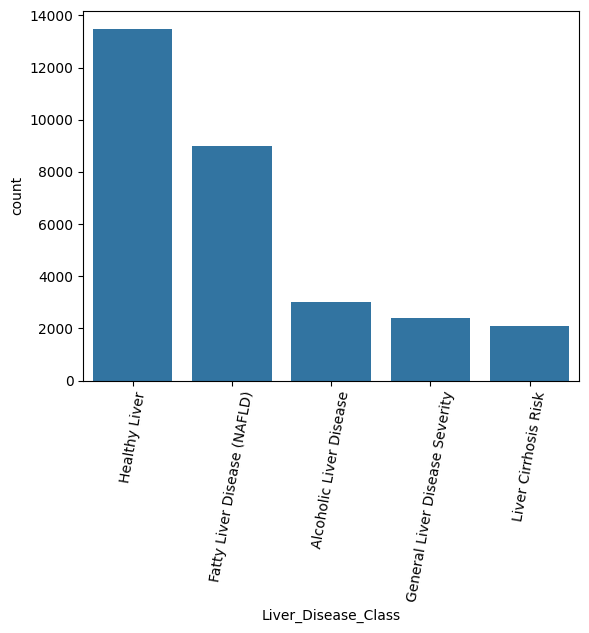

In [34]:
sns.barplot(x=df_training['Liver_Disease_Class'].value_counts().index,y=df_training['Liver_Disease_Class'].value_counts())
plt.xticks(rotation=80)
plt.show()

The target variable exhibits a mild class imbalance, with Healthy Liver representing the largest proportion (45%), while other liver disease categories are moderately underrepresented. Therefore, evaluation metrics beyond accuracy, such as F1-score, are required to ensure fair performance across all classes. or using balancing techniques may help in improving model performance

### Studying features distributions

This section explores the distribution of features to understand their ranges, detect potential anomalies, and gain insights into the underlying patterns within the dataset before model training.

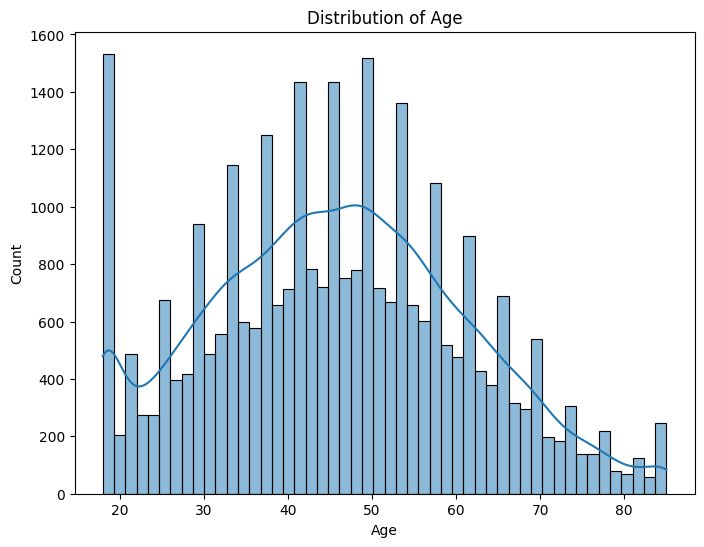

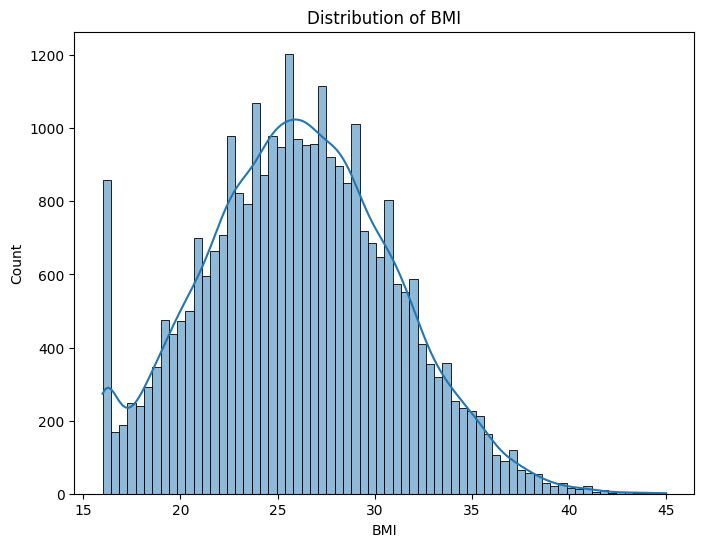

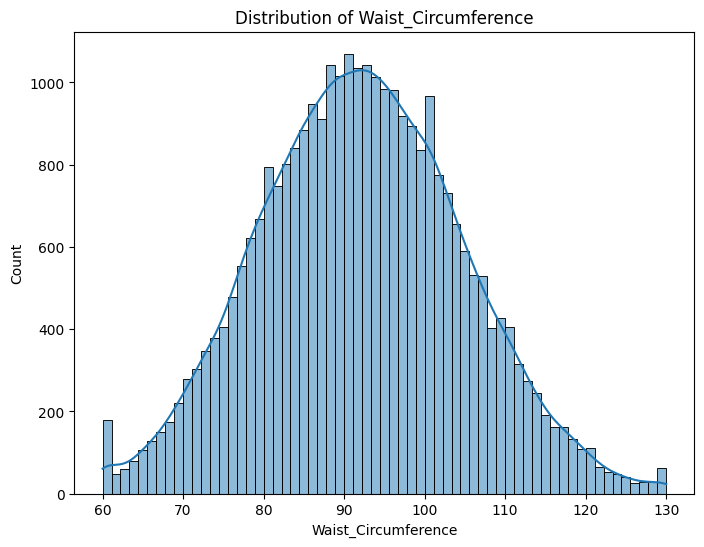

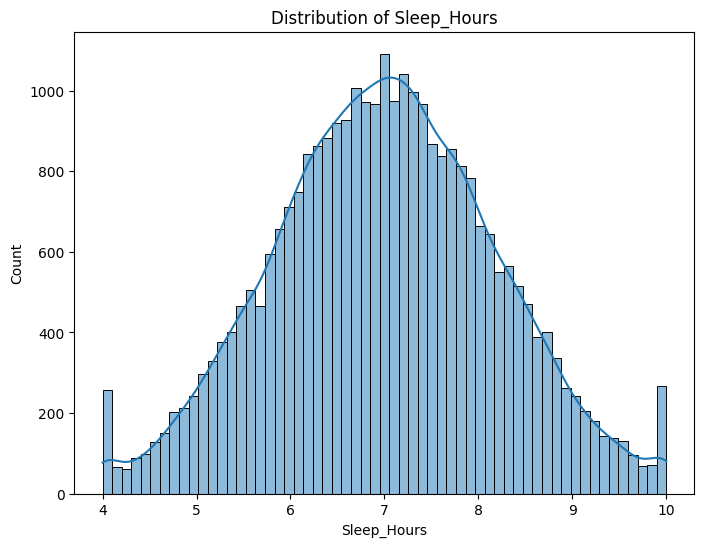

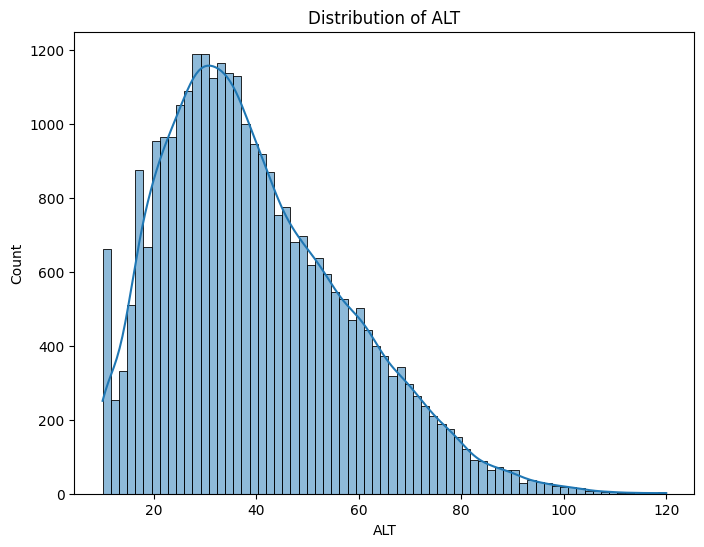

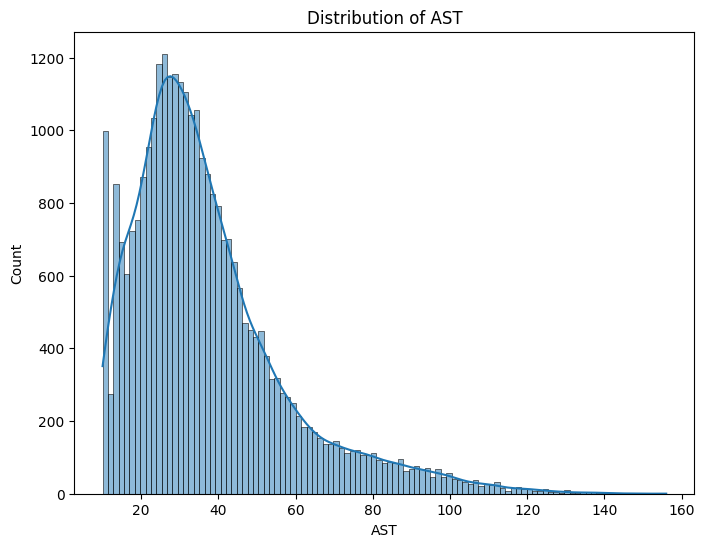

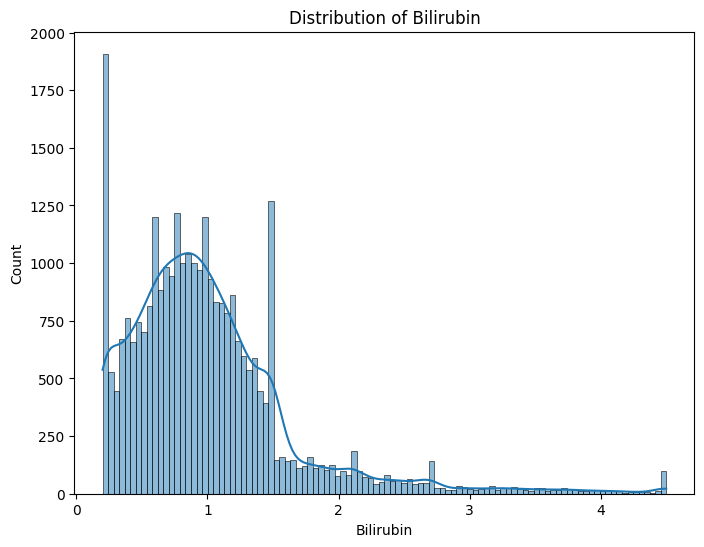

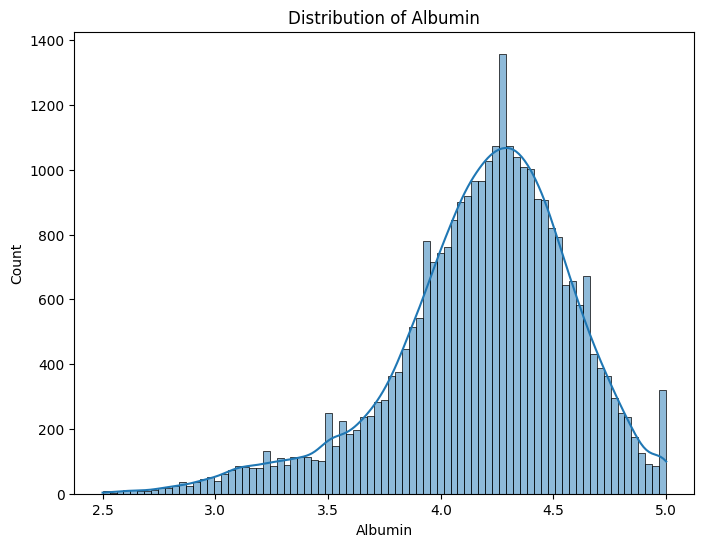

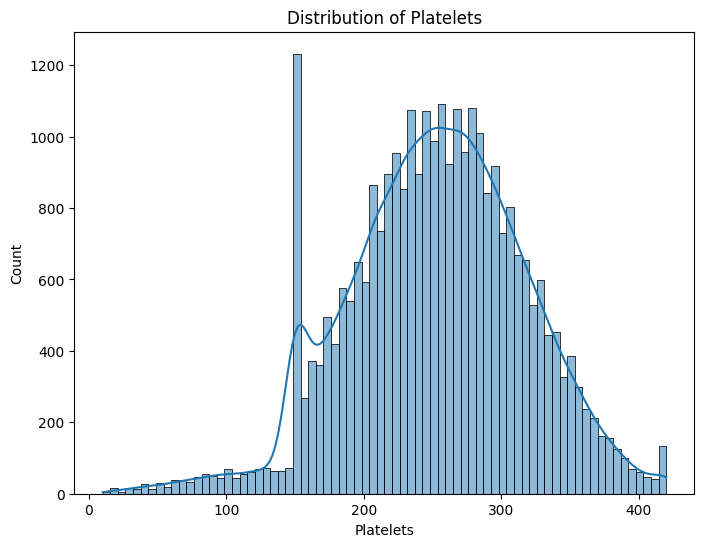

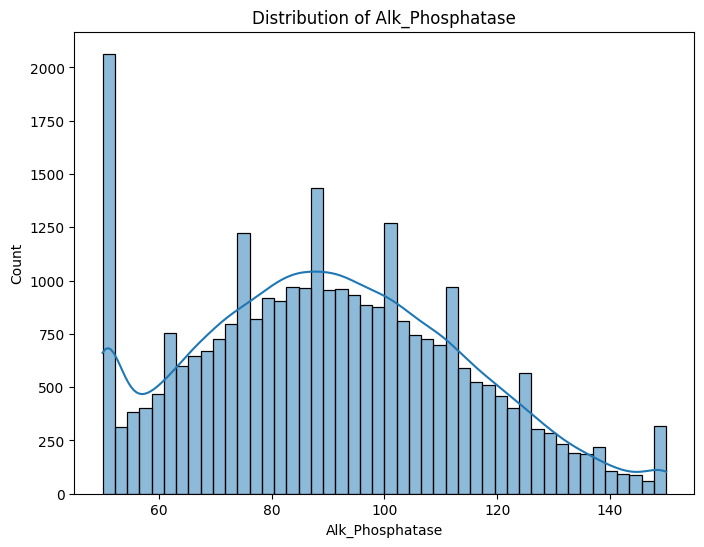

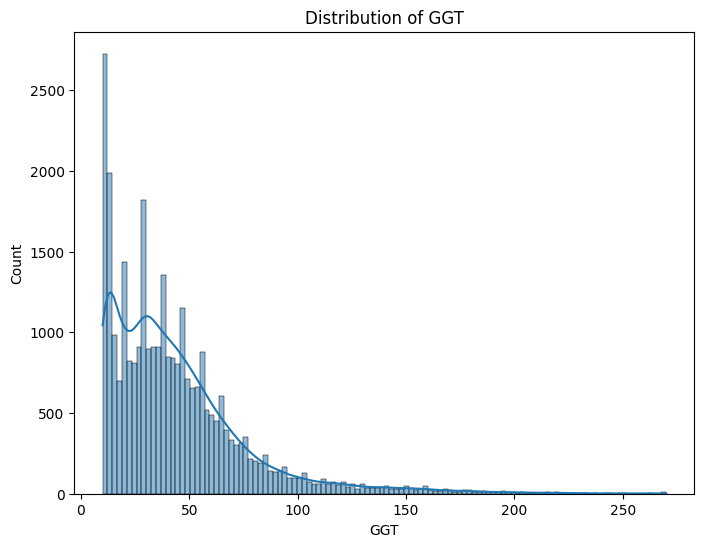

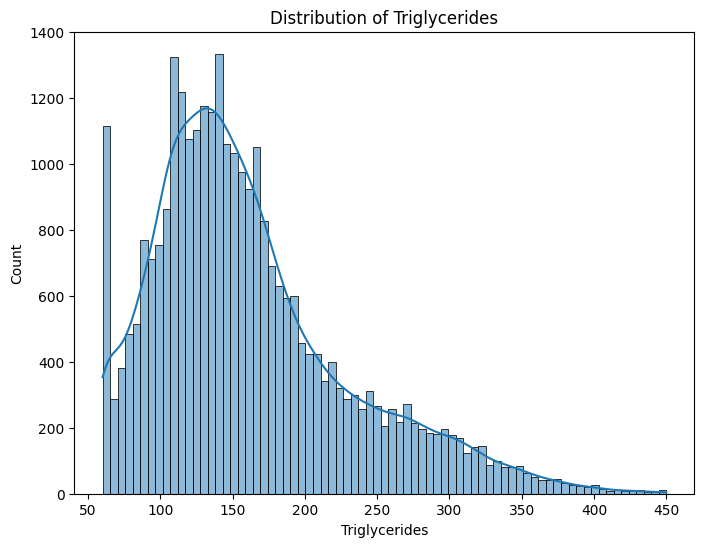

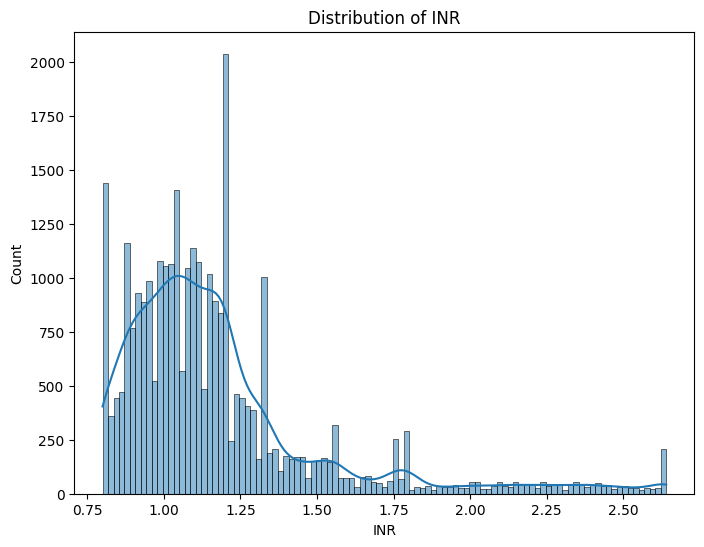

In [35]:
# selecting numeric features
numeric_features = df_training.select_dtypes(exclude="object").columns
# selectig binary columns
binary_cols = [col for col in numeric_features if df_training[col].max() == 1 and df_training[col].min() == 0]

# visualizing numeric columns excluding binary columns
for col in numeric_features.drop(binary_cols):
    plt.figure(figsize=(8, 6))
    sns.histplot(df_training[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()



### Evaluating correlations between numerical variables using a correlation matrix.

Correlation analysis is performed to quantify pairwise relationships among numerical variables and to detect potential multicollinearity issues affecting model performance.

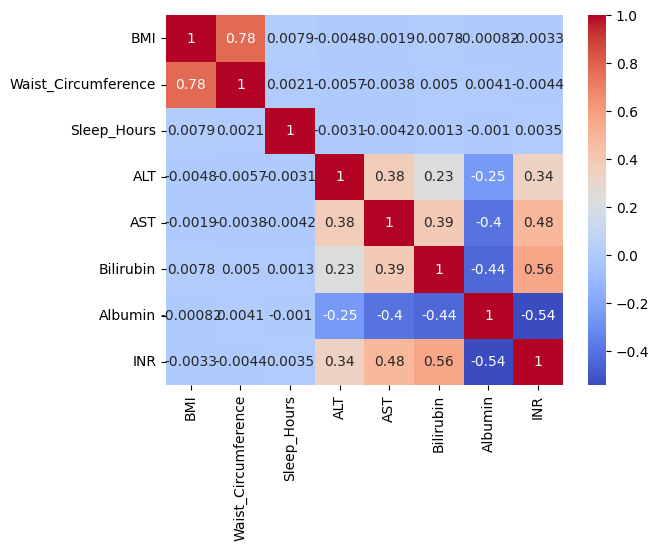

In [36]:
# computing pearson correlation for numeric features
numeric_features = df_training.select_dtypes(include="float64").columns
corr_matrix = df_training[numeric_features].corr(method='pearson')
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

The correlation matrix shows generally low-to-moderate relationships between most features. A notable correlation is observed between BMI and Waist Circumference (0.78). Most other features show weak to moderate correlations, suggesting limited multicollinearity across the dataset.

### Assessing categorical feature cardinality to guide encoding decisions.

Evaluating Features with high cardinality to decide between encoding techniques such as one-hot encoding, target encoding, or grouping to reduce dimensionality and avoid sparse feature space.

In [37]:
df_training.select_dtypes(include="object").nunique()

,0
Gender,2
Occupation,8
Obesity_Class,6
Diet_Quality,3
Physical_Activity,4
Smoking_Status,3
Alcohol_Consumption,3
Medication_History,4
Source,10
Liver_Disease_Class,5


Categorical features mostly exhibit low to moderate cardinality, making One-Hot Encoding suitable for most variables



In [38]:
cardinality = []
for col in df_training.select_dtypes(include="object").columns:
  cardinality.append({'col_name': col, 'unique_values': df_training[col].unique()})
cardinality_df = pd.DataFrame(cardinality)
print(cardinality)


[{'col_name': 'Gender', 'unique_values': array(['Female', 'Male'], dtype=object)}, {'col_name': 'Occupation', 'unique_values': array(['Healthcare Worker', 'Farmer', 'Student', 'Office Worker',
       'Housewife', 'Business', 'Retired', 'Laborer'], dtype=object)}, {'col_name': 'Obesity_Class', 'unique_values': array(['Overweight', 'Obesity I', 'Normal', 'Underweight', 'Obesity II',
       'Obesity III'], dtype=object)}, {'col_name': 'Diet_Quality', 'unique_values': array(['Poor', 'Average', 'Healthy'], dtype=object)}, {'col_name': 'Physical_Activity', 'unique_values': array(['Sedentary', 'Low', 'High', 'Moderate'], dtype=object)}, {'col_name': 'Smoking_Status', 'unique_values': array(['Former', 'Current', 'Never'], dtype=object)}, {'col_name': 'Alcohol_Consumption', 'unique_values': array([nan, 'Moderate', 'High', 'Low'], dtype=object)}, {'col_name': 'Medication_History', 'unique_values': array(['Steroids', 'Diabetes Medication', 'Hepatotoxic Drugs', nan,
       'Hypertension Medication

| Column              | Unique Values                                                                                                                                        |
| ------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------- |
| Gender              | Female, Male                                                                                                                                         |
| Occupation          | Healthcare Worker, Farmer, Student, Office Worker, Housewife, Business, Retired, Laborer                                                             |
| Obesity_Class       | Overweight, Obesity I, Normal, Underweight, Obesity II, Obesity III                                                                                  |
| Diet_Quality        | Poor, Average, Healthy                                                                                                                               |
| Physical_Activity   | Sedentary, Low, High, Moderate                                                                                                                       |
| Smoking_Status      | Former, Current, Never                                                                                                                               |
| Alcohol_Consumption | NaN, Moderate, High, Low                                                                                                                             |
| Medication_History  | Steroids, Diabetes Medication, Hepatotoxic Drugs, NaN, Hypertension Medication                                                                       |
| Source              | Johns Hopkins Hospital, Cleveland Clinic, KGMU, Mount Sinai Hospital, CMC Vellore, Massachusetts General Hospital, PGIMER, SGPGI, Mayo Clinic, AIIMS |
| Liver_Disease_Class | Healthy Liver, Fatty Liver Disease (NAFLD), Alcoholic Liver Disease, General Liver Disease Severity, Liver Cirrhosis Risk                            |


### **Dropping unnecessary columns**

The 'Source' feature indicates where the record was obtained from and does not provide meaningful information for model learning.

The 'BMI' feature shows high multicollinearity with 'Weight' feature. so it is removed to reduce redundancy and improve model stability.

In [39]:
drop_col = ["Source", 'BMI']
df_training = df_training.drop(columns=drop_col)


# 🔧**4. Preprocessing**


## **Split**
In this stage, the dataset was split into training, validation, and testing sets to ensure proper model evaluation and prevent overfitting.

The data was divided as follows:

- Training set: Used to train the machine learning models.
- Validation set: Used for hyperparameter tuning and model selection.
- Testing set: Used only once at the end to evaluate the final model performance on unseen data.

This separation ensures that the model is evaluated on unseen data and provides a reliable estimate of its generalization ability.

A stratified split was applied to preserve the distribution of the target variable across all subsets.

In [42]:
target = 'Liver_Disease_Class'
y = df_training[target]
X = df_training.drop(columns=target)
# splitting data into training and validating sets
X_train, X_validation, y_train, y_validation = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)

### **Encoding nominal and oredenal variables**
In this step, categorical features are analyzed to determine the most appropriate encoding technique. Ordinal Encoding is applied to features with meaningful order, while One-Hot Encoding is used for nominal features without inherent ranking.

In [43]:
ordinal_cols = [
    'Diet_Quality',
    'Physical_Activity',
    'Obesity_Class'
]

ordinal_categories = [
    ['Poor', 'Average', 'Healthy'],
    ['Sedentary', 'Low', 'Moderate', 'High'],
    ['Underweight', 'Normal', 'Overweight',
     'Obesity I', 'Obesity II', 'Obesity III']
]

onehot_cols = [
    'Gender',
    'Occupation',
    'Smoking_Status',
    'Alcohol_Consumption',
    'Medication_History'
]

numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns

# pipline to handle ordinal features
ordinal_pipline = Pipeline(steps = [
                                      ('imputer',SimpleImputer(strategy='constant', fill_value='N/A')),
                                      ('ordinal', OrdinalEncoder(categories=ordinal_categories))


])

# pipline to handle nominal features
onehot_pipline = Pipeline(steps=[
                                  ('imputer', SimpleImputer(strategy='constant', fill_value='N/A')),
                                  ('onehot', OneHotEncoder(handle_unknown= 'ignore'))



                                 ])


preprocessor = ColumnTransformer(
    transformers=[

        (
            'ordinal',
            ordinal_pipline,
            ordinal_cols
        ),
        (
            'onehot',
            onehot_pipline,
            onehot_cols
        ),
        (
            'scaler',
            StandardScaler(),
            numeric_cols

        )
    ],
    remainder='drop' # to keep not transformed data in the df [not drop them]
)


In [44]:
# to assert all columns are handeled through pipline
assert len(ordinal_cols + onehot_cols) == len(X_train.select_dtypes(include= 'object').columns)

# 🤖 **5. Build Model**

## **5.1 Baseline**

In [45]:
df_training['Liver_Disease_Class'].value_counts(normalize=True).max()

0.45

## **5.2 Iterate**

### KNN pipeline

In [46]:
knn_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=5))
])

In [47]:
knn_model.fit(X_train, y_train)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='N/A',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Poor',
                                                                                               'Average',
                                                                                               'Healthy'],
                                                                                              ['Sedentary',
                                                                                               'Low',
                                                                                               'Moderate',
                                                                                               'High'],
                                                                                              ['Underweight',
                                                                                               'Normal',
                                                                                               'Overweight',
                                                                                               'Obesity '
                                                                                               'I',
                                                                                               'Obesity '
                                                                                               'II',
                                                                                               'Obesity '
                                                                                               'III']]))]),
                                                  ['Diet_...
                                                  Index(['Age', 'Waist_Circumference', 'Sleep_Hours', 'Sym_Fatigue',
       'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites',
       'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes',
       'Comorb_Hypertension', 'Comorb_Genetic_History', 'ALT', 'AST',
       'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase', 'GGT',
       'Triglycerides', 'INR'],
      dtype='object'))])),
                ('model', KNeighborsClassifier())])

In [48]:
# Knn model evaluation
knn_pred = knn_model.predict(X_validation)
print("KNN accuracy:", accuracy_score(y_validation, knn_pred))

KNN accuracy: 0.8543333333333333


### Decision Tree pipeline

In [49]:
# Decision Tree model evaluation
tree_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42,  criterion='entropy', class_weight='balanced'))
])


In [50]:
tree_model.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('ordinal',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='N/A',
                                                                                 strategy='constant')),
                                                                  ('ordinal',
                                                                   OrdinalEncoder(categories=[['Poor',
                                                                                               'Average',
                                                                                               'Healthy'],
                                                                                              ['Sedentary',
                                                                                               'Low',
                                                                                               'Moderate',
                                                                                               'High'],
                                                                                              ['Underweight',
                                                                                               'Normal',
                                                                                               'Overweight',
                                                                                               'Obesity '
                                                                                               'I',
                                                                                               'Obesity '
                                                                                               'II',
                                                                                               'Obesity '
                                                                                               'III']]))]),
                                                  ['Diet_...
       'Sym_Jaundice', 'Sym_Abdominal_Pain', 'Sym_Itching', 'Sym_Ascites',
       'Sym_Dark_Urine', 'Sym_Weight_Loss', 'Comorb_Diabetes',
       'Comorb_Hypertension', 'Comorb_Genetic_History', 'ALT', 'AST',
       'Bilirubin', 'Albumin', 'Platelets', 'Alk_Phosphatase', 'GGT',
       'Triglycerides', 'INR'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(class_weight='balanced',
                                        criterion='entropy',
                                        random_state=42))])

In [51]:
tree_pred = tree_model.predict(X_validation)
print("Tree accuracy:", accuracy_score(y_validation, tree_pred))


Tree accuracy: 0.9236666666666666


##**5.3 Hyperparameter Tuning**

### **Hyperparameter Tuning for KNN**

In this step, different hyperparameter values are evaluated to identify the optimal model configuration and improve generalization performance while reducing the risk of overfitting.

In [52]:
training_scores = []
validation_scores = []
for k in range(1, 21):
    knn_model_test = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=k, metric= 'euclidean'))
    ])
    knn_model_test.fit(X_train, y_train)
    training_scores.append(knn_model_test.score(X_train, y_train))
    validation_scores.append(knn_model_test.score(X_validation, y_validation))

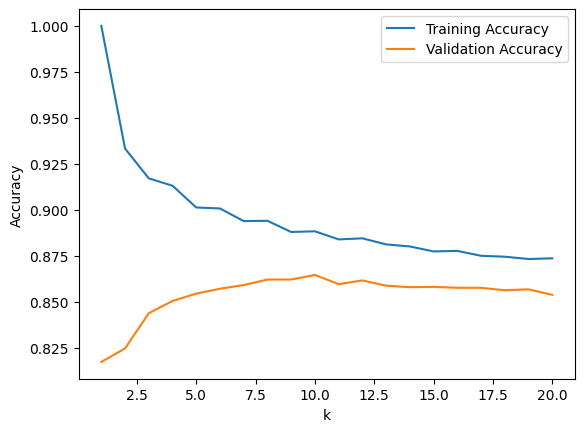

In [53]:
# ploting hyperparameters
plt.plot(range(1,21), training_scores, label='Training Accuracy')
plt.plot(range(1,21), validation_scores, label='Validation Accuracy')
plt.xlabel('k')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

According to the above visualization, the optimal value of k is 10, as it improves the model’s generalization performance while reducing the risk of overfitting.

In [54]:
knn_model_production = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', KNeighborsClassifier(n_neighbors=10, metric= 'euclidean'))
])
knn_model_production.fit(X_train, y_train)
print(knn_model_production.score(X_validation, y_validation))

0.8645


### **Hyperparameter Tuning for Decision Tree**


In [55]:
# tree depth
tree_depth = tree_model.named_steps['model'].get_depth()
print("Tree depth:", tree_depth)

Tree depth: 29


In [56]:
depth_hyperparams = range(1, 27, 2)

In [57]:
# Hyperparameter Tuning
training_scores = []
validation_scores = []
for depth in depth_hyperparams:
    tree_model_test = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', DecisionTreeClassifier(random_state=42, criterion='entropy',class_weight='balanced'))
    ])
    tree_model_test.set_params(model__max_depth=depth)
    tree_model_test.fit(X_train, y_train)
    training_scores.append(tree_model_test.score(X_train, y_train))
    validation_scores.append(tree_model_test.score(X_validation, y_validation))

In [58]:
print(training_scores)
print(validation_scores)

[0.17, 0.798125, 0.850625, 0.8995833333333333, 0.931375, 0.95275, 0.960375, 0.9726666666666667, 0.9855833333333334, 0.9929166666666667, 0.9972083333333334, 0.9987916666666666, 0.9997083333333333]
[0.17, 0.7963333333333333, 0.8453333333333334, 0.891, 0.9163333333333333, 0.9301666666666667, 0.9251666666666667, 0.9271666666666667, 0.9276666666666666, 0.9265, 0.9273333333333333, 0.9266666666666666, 0.9255]


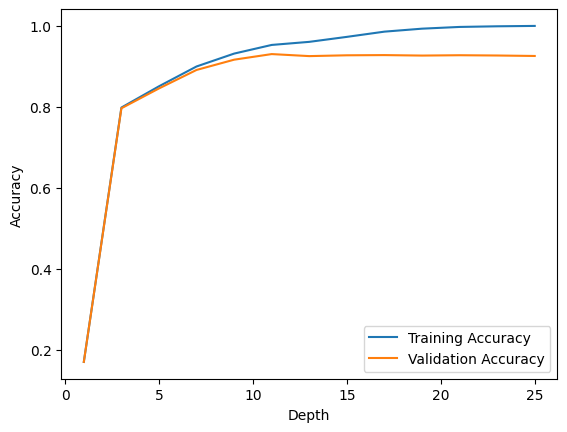

In [59]:
# plot 'depth_hyperparams', training_acc'
plt.plot(depth_hyperparams, training_scores, label='Training Accuracy')
plt.plot(depth_hyperparams, validation_scores, label='Validation Accuracy')
plt.xlabel('Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Based on the above visualization, the recommended depth for the Decision Tree model is between 10 and 11, as this range provides strong performance on both the training and validation datasets while reducing the risk of overfitting.

In [60]:
tree_model_production = Pipeline(steps =[
                                           ('preprocess', preprocessor),
                                           ('model', DecisionTreeClassifier(random_state= 42, max_depth= 11,criterion='entropy', class_weight='balanced'))
                                        ])
tree_model_production.fit(X_train, y_train)
print(tree_model_production.score(X_validation, y_validation))





0.9301666666666667


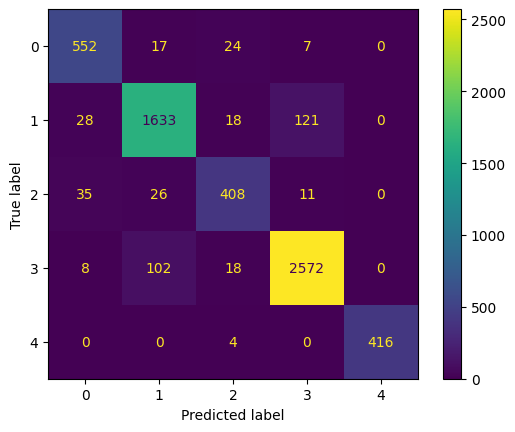

In [61]:
y_pred = tree_model_production.predict(X_validation)

cm = confusion_matrix(y_validation, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot()

In [62]:
# getting percision, recall , f1 scores
print(f1_score(y_validation, y_pred, average='weighted'))
print(precision_score(y_validation, y_pred, average='weighted'))
print(recall_score(y_validation, y_pred, average='weighted'))

0.9301416947209565
0.9302177149719371
0.9301666666666667


**Extract Features importances**

In this step, feature importance scores are extracted to identify the most influential variables contributing to the model’s predictions and understand which features have the greatest impact on liver disease classification.



In [63]:
features = [i.split('__')[-1] for i in tree_model_production.named_steps['preprocess'].get_feature_names_out()]
importances = tree_model_production.named_steps['model'].feature_importances_

In [64]:
features_imp = pd.Series(importances, index=features).sort_values(ascending = False).head(10)
print(features_imp)


INR               0.514122
Triglycerides     0.125627
Albumin           0.108108
AST               0.089615
ALT               0.044888
GGT               0.039911
Sym_Jaundice      0.022118
Bilirubin         0.017472
Sym_Fatigue       0.016441
Sym_Dark_Urine    0.006454
dtype: float64


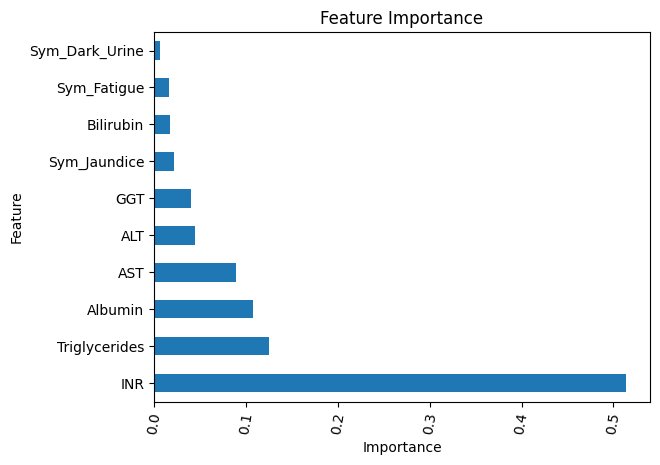

In [65]:
features_imp.plot(kind='barh')
plt.xticks(rotation=80)
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance')
plt.show()

## **5.4 Evaluate**

At this section, the model will be evaluated using testing dataset. as the testing and training datasets are seperated in two files. testing dataset will be loaded and wrangled to be ready for testing phase and model evaluation

### **Wrangling test dataset**

In [66]:
df_testing.head()

,Age,Gender,Occupation,BMI,Obesity_Class,Waist_Circumference,Diet_Quality,Physical_Activity,Sleep_Hours,Smoking_Status,...,Bilirubin,Albumin,Platelets,Alk_Phosphatase,GGT,Triglycerides,INR,Medication_History,Source,Liver_Disease_Class
0,47,Male,Farmer,40.2,Obesity III,129.3,Poor,Sedentary,6.4,Current,...,3.62,3.06,241,113,85,212,2.53,Diabetes Medication,Massachusetts General Hospital,Liver Cirrhosis Risk
1,55,Male,Office Worker,20.5,Normal,69.2,Average,Low,6.0,Former,...,1.32,4.35,370,100,10,172,0.80,Hypertension Medication,PGIMER,Healthy Liver
2,55,Female,Retired,31.6,Obesity I,98.3,Poor,Sedentary,4.6,Never,...,0.90,4.29,247,107,69,68,1.20,Diabetes Medication,Johns Hopkins Hospital,General Liver Disease Severity
3,56,Male,Housewife,31.3,Obesity I,120.1,Healthy,Moderate,7.1,Former,...,0.80,4.28,391,79,93,60,1.43,Steroids,KGMU,Alcoholic Liver Disease
4,55,Male,Office Worker,27.3,Overweight,92.7,Poor,Moderate,6.7,Former,...,1.08,3.77,255,81,41,72,1.00,Steroids,Cleveland Clinic,Healthy Liver


In [67]:
df_testing.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Age                     5500 non-null   int64  
 1   Gender                  5500 non-null   object 
 2   Occupation              5500 non-null   object 
 3   BMI                     5500 non-null   float64
 4   Obesity_Class           5500 non-null   object 
 5   Waist_Circumference     5500 non-null   float64
 6   Diet_Quality            5500 non-null   object 
 7   Physical_Activity       5500 non-null   object 
 8   Sleep_Hours             5500 non-null   float64
 9   Smoking_Status          5500 non-null   object 
 10  Alcohol_Consumption     4060 non-null   object 
 11  Sym_Fatigue             5500 non-null   int64  
 12  Sym_Jaundice            5500 non-null   int64  
 13  Sym_Abdominal_Pain      5500 non-null   int64  
 14  Sym_Itching             5500 non-null   

In [68]:
drop_col = ["Source"]
df_testing = df_testing.drop(columns=drop_col)

In [69]:
X_test = df_testing.drop(columns=target)
y_test = df_testing[target]

### **KNN model evaluation**

In [70]:
knn_test_pred = knn_model_production.predict(X_test)
print( 'accuracy_score: ', accuracy_score(y_test, knn_test_pred))
print('f1_score: ',f1_score(y_test, knn_test_pred, average='weighted'))
print('precision_score: ',precision_score(y_test, knn_test_pred, average='weighted'))
print('recall_score: ',recall_score(y_test, knn_test_pred, average='weighted'))

accuracy_score:  0.8510909090909091
f1_score:  0.8436588977199498
precision_score:  0.8497189246909671
recall_score:  0.8510909090909091


### **Decision Tree model evaluation**

In [71]:
DecisionT_test_pred = tree_model_production.predict(X_test)

In [72]:
print( 'accuracy_score: ', accuracy_score(y_test, DecisionT_test_pred))
print('f1_score: ',f1_score(y_test, DecisionT_test_pred, average='weighted'))
print('precision_score: ',precision_score(y_test, DecisionT_test_pred, average='weighted'))
print('recall_score: ',recall_score(y_test, DecisionT_test_pred, average='weighted'))

accuracy_score:  0.9314545454545454
f1_score:  0.9316085436389214
precision_score:  0.9318324521639237
recall_score:  0.9314545454545454


# 💡 **6.Communicate Results**

### **6.1  Model Performance Summary**

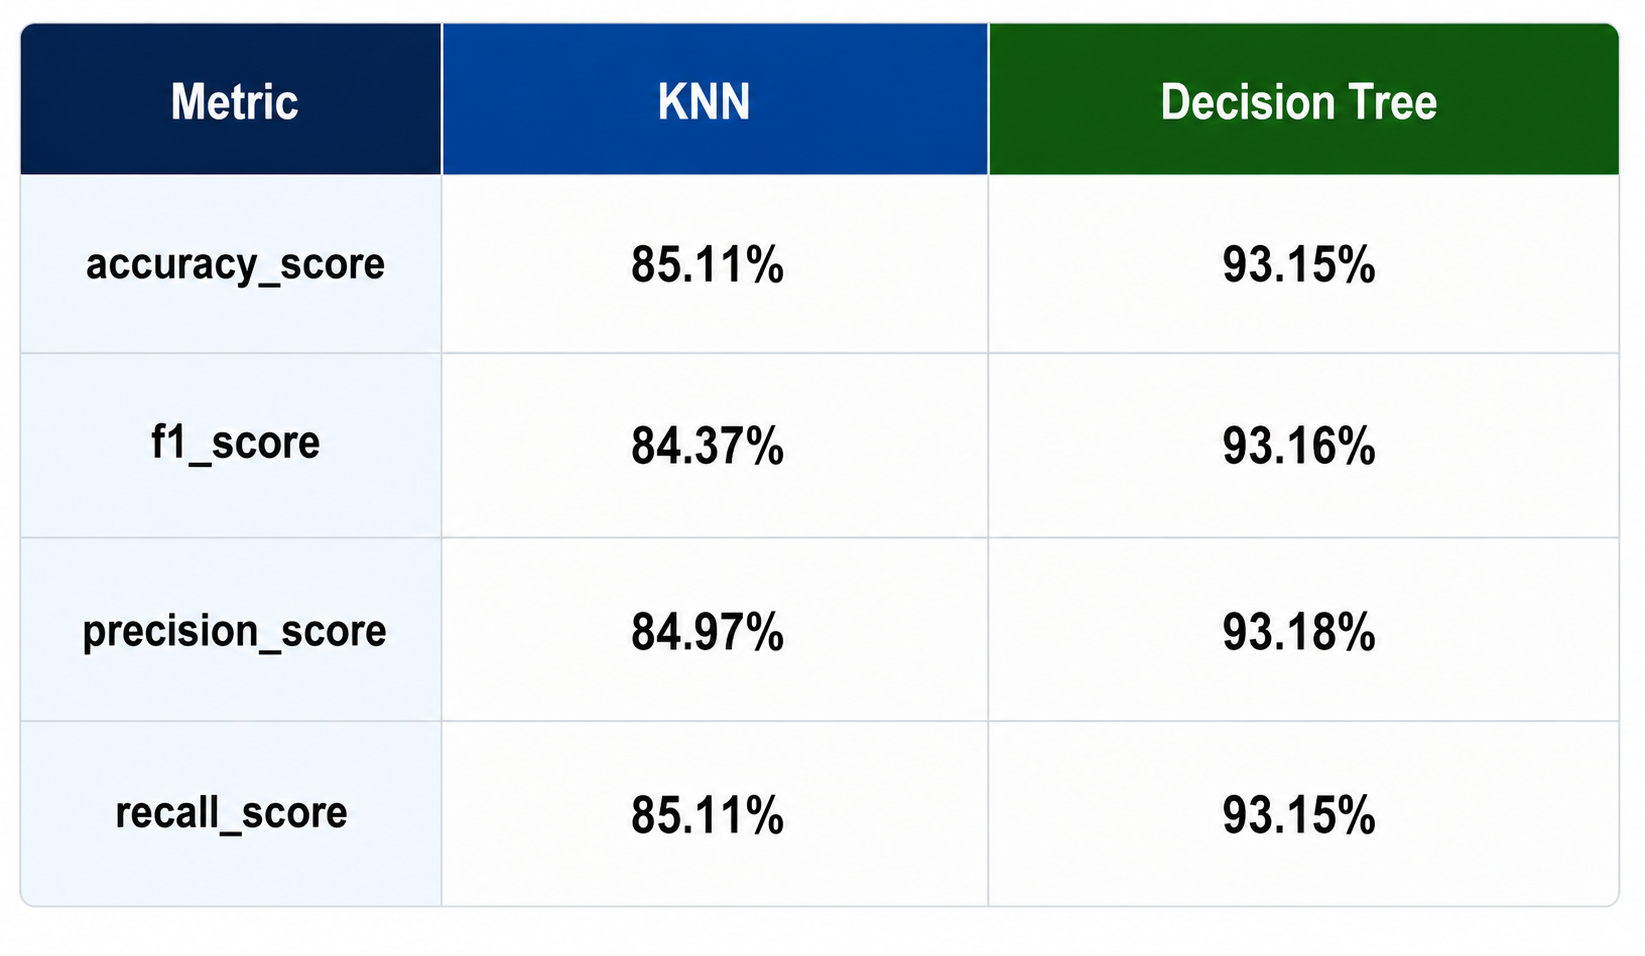

### **6.2 Key Findings**
- Decision Tree outperformed KNN in all evaluation metrics.
- After hyperparameter tuning, the best value for K was 10 and the optimal max depth was 11  to get the best perfomance of the model.

- The model identified liver function biomarkers (INR, AST, ALT, Albumin) as the most influential features in prediction


### **6.3 Recommendations**

✔ using more data will be helpful for model to increase performance

✔ Future work may include experimenting with ensemble models such as Random Forest and XGBoost to further improve model performance and robustness.


# **7.Model Serialization**

In [74]:
joblib.dump(tree_model_production, "DTmodel.pkl")

['DTmodel.pkl']

In [13]:
df_testing.iloc[15].to_dict()

{'Age': 34,
 'Gender': 'Female',
 'Occupation': 'Office Worker',
 'BMI': 33.5,
 'Obesity_Class': 'Obesity I',
 'Waist_Circumference': 95.2,
 'Diet_Quality': 'Average',
 'Physical_Activity': 'Low',
 'Sleep_Hours': 7.2,
 'Smoking_Status': 'Current',
 'Alcohol_Consumption': 'Low',
 'Sym_Fatigue': 0,
 'Sym_Jaundice': 0,
 'Sym_Abdominal_Pain': 0,
 'Sym_Itching': 0,
 'Sym_Ascites': 0,
 'Sym_Dark_Urine': 0,
 'Sym_Weight_Loss': 0,
 'Comorb_Diabetes': 0,
 'Comorb_Hypertension': 0,
 'Comorb_Genetic_History': 0,
 'ALT': 26.69,
 'AST': 22.57,
 'Bilirubin': 0.94,
 'Albumin': 4.36,
 'Platelets': 287,
 'Alk_Phosphatase': 93,
 'GGT': 38,
 'Triglycerides': 133,
 'INR': 0.9,
 'Medication_History': 'Steroids',
 'Source': 'Massachusetts General Hospital',
 'Liver_Disease_Class': 'Healthy Liver'}